In [ ]:
#This project demonstrates how a Denoising Autoencoder can remove noise from handwritten digit images.
#The model is trained using the MNIST dataset, where noisy images are provided as inputs and clean images are used as targets.
#The autoencoder learns meaningful image representations and reconstructs cleaner versions of noisy images.

In [ ]:
#Problem Statement

#Design and implement a deep learning-based Denoising Autoencoder capable of removing noise from handwritten digit images using the MNIST dataset.
#The model should learn to reconstruct clean images from noisy inputs and generate denoised outputs while preserving the important features of each digit.
#Finally, compare the original, noisy, and reconstructed images to evaluate the model's denoising performance.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [1]:
import zipfile
with zipfile.ZipFile('/content/archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content')
print("Dataset extracted successfully!")

Dataset extracted successfully!


In [2]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_mnist_images(folder_path):
    images = []
    for label in range(10):
        label_folder = os.path.join(folder_path, str(label))
        for filename in os.listdir(label_folder):
            img_path = os.path.join(label_folder, filename)
            img = load_img(img_path, color_mode="grayscale", target_size=(28,28))
            img = img_to_array(img) / 255.0
            images.append(img)

    return np.array(images)

x_train = load_mnist_images("/content/mnist_png/training")
x_test = load_mnist_images("/content/mnist_png/testing")
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (60000, 28, 28, 1)
Testing images: (10000, 28, 28, 1)


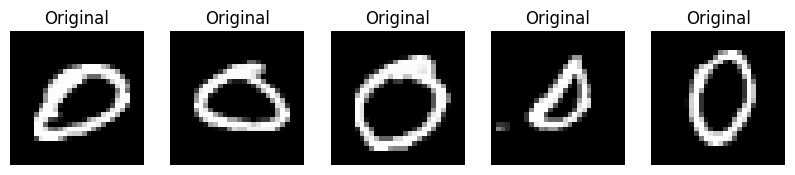

In [5]:
# Display some original training images

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")
plt.show()

Visualizing the original images helps understand the quality of the dataset before any modifications.

In [6]:
# Add Gaussian noise to images

noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
print("Noise added successfully!")

Noise added successfully!


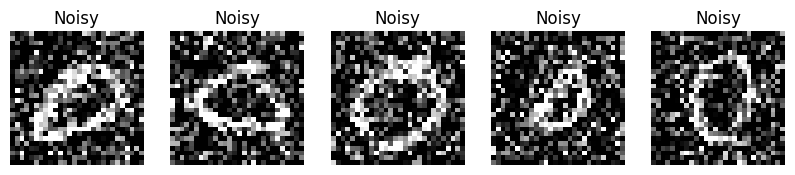

In [7]:
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")
plt.show()

Gaussian noise was successfully added to the training and testing images. The noisy images appear distorted compared to the original images while still preserving the digit structure. The goal of the denoising autoencoder is to learn how to remove this noise and reconstruct images that are as close as possible to the original handwritten digits.

In [10]:
# Build the Denoising Autoencoder
input_img = Input(shape=(28, 28, 1))
x = layers.Flatten()(input_img)

encoded = Dense(128, activation="relu")(x)
encoded = Dense(64, activation="relu")(encoded)
bottleneck = Dense(32, activation="relu")(encoded)

decoded = Dense(64, activation="relu")(bottleneck)
decoded = Dense(128, activation="relu")(decoded)
decoded = Dense(28 * 28, activation="sigmoid")(decoded)

output_img = layers.Reshape((28, 28, 1))(decoded)
autoencoder = Model(input_img, output_img)
print("Autoencoder model built successfully!")

Autoencoder model built successfully!


The encoder compresses the noisy input image into a lower dimensional representation, while the decoder reconstructs the image back to its original size. This architecture will learn to remove noise from handwritten digit images during training.The encoder extracts the important features of the noisy image, the bottleneck stores the compressed representation, and the decoder reconstructs the clean image.

In [11]:
# Compile the Autoencoder
autoencoder.compile(optimizer=Adam(),loss="binary_crossentropy")
print("Autoencoder compiled successfully!")

Autoencoder compiled successfully!


Compiling the model prepares it for training. Adam is an efficient optimization algorithm that speeds up learning, while binary cross entropy is suitable because the image pixel values are normalized between 0 and 1.

In [16]:
# Train the Autoencoder

history = autoencoder.fit( x_train_noisy, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test_noisy, x_test))
print("Training completed successfully!")

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1328 - val_loss: 0.1321
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.1314 - val_loss: 0.1304
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.1302 - val_loss: 0.1296
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1292 - val_loss: 0.1286
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1282 - val_loss: 0.1285
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1274 - val_loss: 0.1270
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1265 - val_loss: 0.1262
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1257 - val_loss: 0.1257
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1250 - val_loss: 0.1252
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1244 - val_loss: 0.1248
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1238 - val_loss: 0.1249
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

During training, the model compares its reconstructed images with the original clean images and updates its weights to reduce the reconstruction error. As the loss decreases over the epochs, the autoencoder becomes better at removing noise while preserving the handwritten digit structure.

In [17]:
# Generate denoised images

denoised_images = autoencoder.predict(x_test_noisy)
print("Denoised images generated successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Denoised images generated successfully!


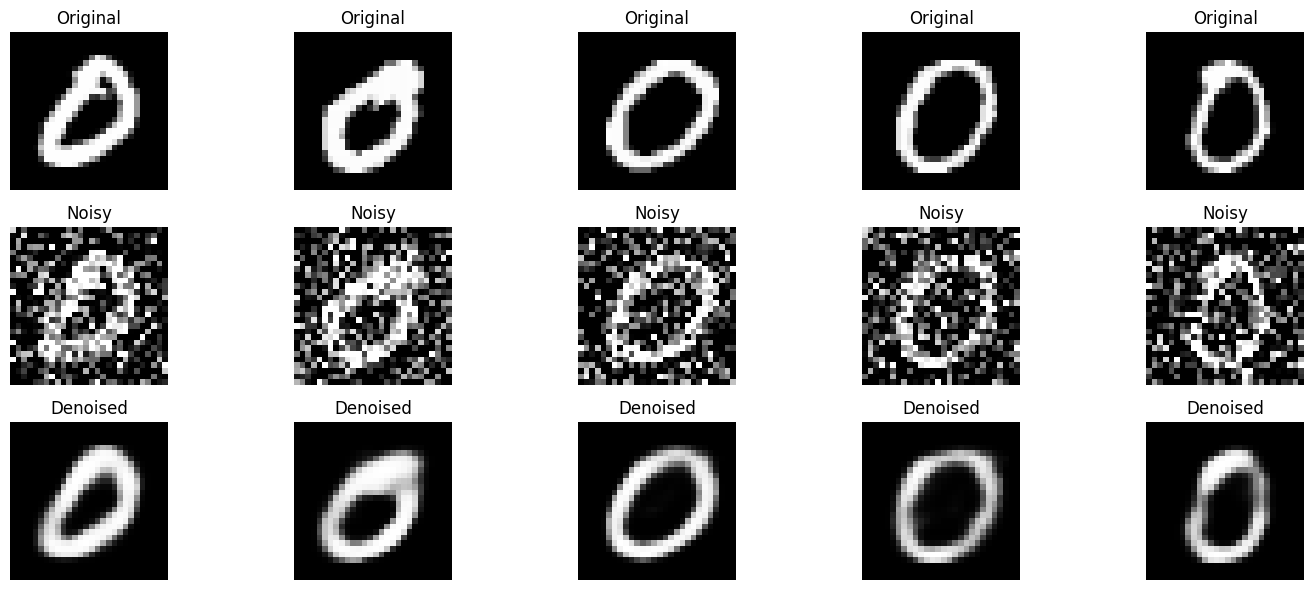

In [18]:
# Display Original, Noisy, and Denoised Images

plt.figure(figsize=(15, 6))
for i in range(5):

    # Original
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3, 5, i + 6)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3, 5, i + 11)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

The trained denoising autoencoder successfully reconstructed cleaner versions of the noisy handwritten digit images. Although some fine details may be slightly blurred, the reconstructed images preserve the main structure of each digit while removing a significant amount of Gaussian noise. This demonstrates that the model learned meaningful image representations and can effectively perform image denoising.

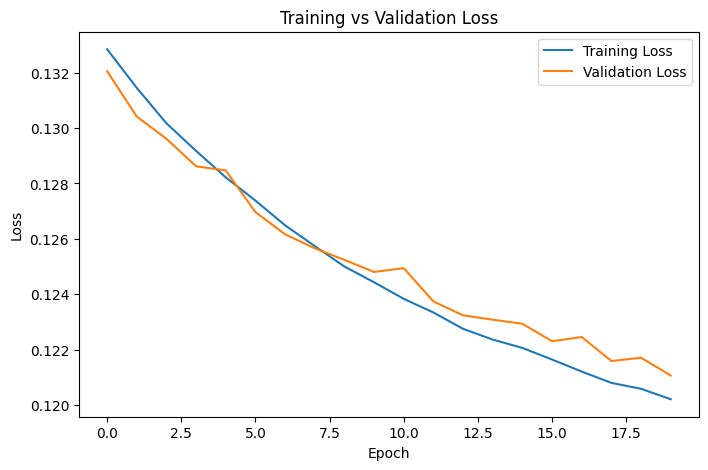

In [19]:
# Plot Training and Validation Loss

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

The training and validation loss decreased consistently over all 20 epochs, indicating that the denoising autoencoder successfully learned to reconstruct clean images from noisy inputs. The validation loss remained close to the training loss throughout the training process, showing that the model generalized well without significant overfitting. The decreasing loss values confirm that the model effectively minimized reconstruction error and improved its denoising capability.

**CONCLUSION**

In this project, I built a denoising autoencoder using the MNIST dataset to remove noise from handwritten digit images. First, the dataset was loaded and preprocessed, then Gaussian noise was added to the images. The autoencoder was trained using the noisy images as input and the original images as the target. After training, the model was able to reconstruct cleaner images while keeping the main digit structure. The training and validation loss also decreased over the epochs, showing that the model learned well. Overall, the project achieved its objective of reducing noise from images and showed how deep learning can be used for image denoising.
